In [27]:
import numpy as np
import tensorflow as tf
import pandas as pd
from sklearn.preprocessing import MinMaxScaler , StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error , mean_absolute_percentage_error, mean_squared_error , r2_score
import matplotlib.pyplot as plt
import warnings
import random
warnings.filterwarnings('ignore')

In [12]:
np.random.seed(42)


In [3]:
df = pd.read_csv("Air Traffic Data Cor Updated.csv",parse_dates=['Date'],index_col='Date')

In [13]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df)

In [33]:
def create_sequences(data, window_size,forecast_horizon,target_indices):
    X, y = [], []
    for i in range(len(data) - window_size - forecast_horizon +1):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size:i+window_size+forecast_horizon, target_indices])
    return np.array(X), np.array(y)


In [34]:
window_size = 12 
forecast_horizon=6
target_indices= [0,1,2,3]
X,y = create_sequences(data_scaled,window_size,forecast_horizon,target_indices)

In [35]:
train_size = int(len(X)*0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [36]:
model = Sequential([
    GRU(64, activation='tanh', input_shape=(window_size, X.shape[2]), dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dense(forecast_horizon * len(target_indices))  # flatten outputs
])
model.compile(optimizer='adam', loss='mse')

In [37]:
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [38]:
history = model.fit(
    X_train, y_train.reshape(y_train.shape[0], -1),
    epochs=100,
    batch_size=8,
    validation_data=(X_test, y_test.reshape(y_test.shape[0], -1)),
    callbacks=[es],
    verbose=1
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.7842 - val_loss: 1.1864
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5967 - val_loss: 1.0350
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4320 - val_loss: 0.9668
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3540 - val_loss: 1.1313
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3126 - val_loss: 1.2548
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2881 - val_loss: 1.5503
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2452 - val_loss: 1.7992
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2820 - val_loss: 1.6771
Epoch 9/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2506 - val_loss: 2.1166
Epoch 10/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2360 - val_loss: 2.5513
Epoch 11/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2243 - val_loss: 2.3226
Epoch 12/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - l

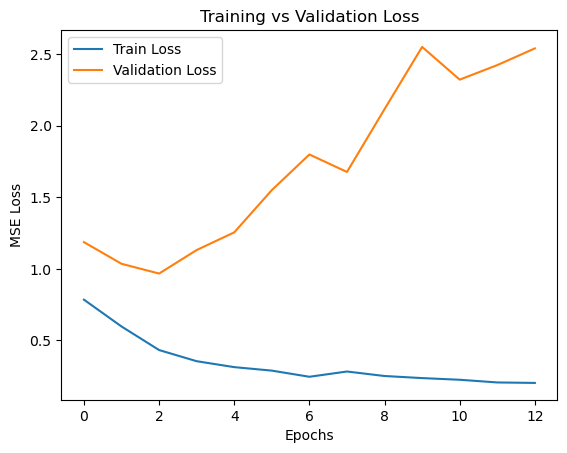

In [39]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

In [25]:
y_pred = model.predict(X_test)

# Inverse transform only target columns
data_scaled_dummy = np.zeros((len(y_pred), data_scaled.shape[1]))
data_scaled_dummy[:, target_indices] = y_pred
y_pred_rescaled = scaler.inverse_transform(data_scaled_dummy)[:, target_indices]

data_scaled_dummy = np.zeros((len(y_test), data_scaled.shape[1]))
data_scaled_dummy[:, target_indices] = y_test
y_test_rescaled = scaler.inverse_transform(data_scaled_dummy)[:, target_indices]

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 367ms/step


In [28]:
for i, col in enumerate(df.columns[target_indices]):
    rmse = np.sqrt(mean_squared_error(y_test_rescaled[:, i], y_pred_rescaled[:, i]))
    r2 = r2_score(y_test_rescaled[:, i], y_pred_rescaled[:, i])
    print(f"{col} → RMSE={rmse:.2f}, R²={r2:.3f}")

domestic passengers → RMSE=1733617.07, R²=-0.024
international passenegrs → RMSE=458515.25, R²=0.224
domestic freight(in tonne) → RMSE=9587.21, R²=-2.479
international freight(in tonne) → RMSE=5399.94, R²=-0.367


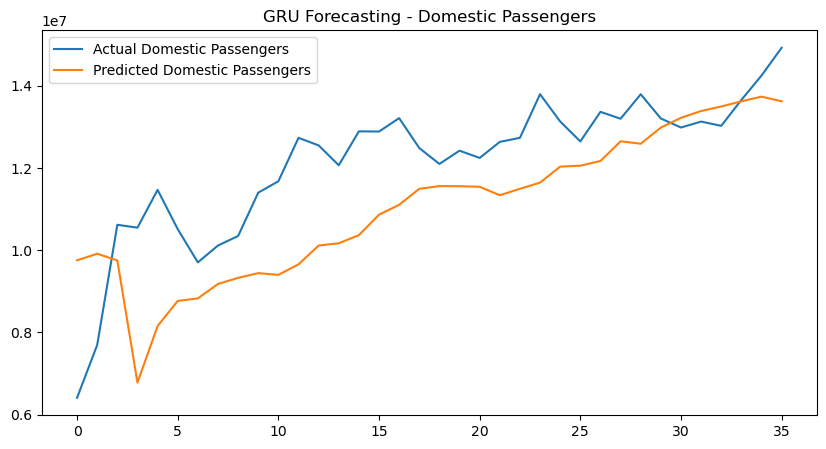

In [29]:
plt.figure(figsize=(10,5))
plt.plot(y_test_rescaled[:,0], label='Actual Domestic Passengers')
plt.plot(y_pred_rescaled[:,0], label='Predicted Domestic Passengers')
plt.legend()
plt.title('GRU Forecasting - Domestic Passengers')
plt.show()